In [1]:
from google.colab import files
uploaded = files.upload()

Saving Student_Projects.zip to Student_Projects.zip


In [2]:
import zipfile

with zipfile.ZipFile("Student_Projects.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")

In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

In [4]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
DATASET_PATH = "/content/dataset"

In [5]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 193 files belonging to 3 classes.
Using 155 files for training.


In [6]:
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 193 files belonging to 3 classes.
Using 38 files for validation.


In [7]:
class_names = train_ds.class_names
print(f"Detected Classes: {class_names}")

Detected Classes: ['CELOSIA ARGENTEA L', 'CROWFOOT GRASS', 'PURPLE CHLORIS']


In [8]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [9]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
])

In [10]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [11]:
inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)
outputs = tf.keras.layers.Dense(len(class_names), activation='softmax')(x)

In [12]:
model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [13]:
history = model.fit(train_ds, validation_data=val_ds, epochs=10)
model.save("plant_model.h5")

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 12s 791ms/step - accuracy: 0.5677 - loss: 1.0468 - val_accuracy: 0.7632 - val_loss: 0.4062
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.8645 - loss: 0.3499 - val_accuracy: 1.0000 - val_loss: 0.1284
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.9484 - loss: 0.1759 - val_accuracy: 0.9474 - val_loss: 0.2005
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.9677 - loss: 0.1016 - val_accuracy: 0.9737 - val_loss: 0.0983
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.9935 - loss: 0.0583 - val_accuracy: 0.9737 - val_loss: 0.0521
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.9806 - loss: 0.0474 - val_accuracy: 0.9737 - val_loss: 0.0491
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.9871 - loss: 0.0245 - val_accuracy: 0.9737 - val_loss: 0.0870
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 1.0000 - loss: 0.0249 - val_accuracy: 0.9737 - val_loss: 0.077

In [14]:
PLANT_DATABASE = {
    "CROWFOOT GRASS": {
        "type": "Weed",
        "risk": "High (Resource Theft & Rapid Spread)",
        "threat_details": "Highly competitive root system. Aggressively steals soil moisture and vital nutrients (like nitrogen) away from your main crops, directly reducing your harvest yield.",
        "advice": "Use targeted post-emergence herbicide. Remove manually before it drops seeds."
    },
    "PURPLE CHLORIS": {
        "type": "Weed",
        "risk": "High (Invasive & Hard to Eradicate)",
        "threat_details": "Spreads very rapidly via wind-blown seeds. Known to develop resistance to standard herbicides and thrives even in poor soil conditions.",
        "advice": "Manual removal recommended early on. If widespread, consult agronomist for specific herbicide rotation."
    },
    "CELOSIA ARGENTEA L": {
        "type": "Useful Plant / Flower",
        "risk": "Low (Benign / Beneficial) 🌿",
        "threat_details": "No threat to crops. It actually attracts helpful pollinators to the farm and can be harvested as an ornamental flower or for traditional medicine.",
        "advice": "Safe to keep. Let it grow to support farm biodiversity."
    }
}

In [15]:
def predict_with_advice(img_path):
    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)
    class_idx = np.argmax(pred)
    label = class_names[class_idx]
    confidence = np.max(pred) * 100

    print(f"\n--- DIAGNOSIS REPORT ---")
    print(f"Prediction: {label} ({confidence:.2f}% confidence)")

    info = PLANT_DATABASE.get(label, {
        "type": "Unknown",
        "risk": "Unknown",
        "threat_details": "No data available.",
        "advice": "Consult local agronomist."
    })

    print(f"Type: {info['type']}")
    print(f"Risk Level: {info['risk']}")
    print(f"Why it matters: {info['threat_details']}")
    print(f"Action Plan: {info['advice']}")
    print("------------------------\n")

    return label

In [16]:
def get_gradcam(img_path, alpha=0.4):
    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    base_model_layer = None
    for layer in model.layers:
        if isinstance(layer, tf.keras.Model) and layer.name != "sequential":
            base_model_layer = layer
            break

    if base_model_layer is None:
        print("Error: Could not find base model.")
        return

    last_conv_layer = base_model_layer.get_layer('out_relu')

    inner_grad_model = tf.keras.Model(
        inputs=base_model_layer.inputs,
        outputs=[last_conv_layer.output, base_model_layer.output]
    )

    processed_img = preprocess_input(np.copy(img_array))

    base_idx = model.layers.index(base_model_layer)

    with tf.GradientTape() as tape:
        conv_outputs, base_predictions = inner_grad_model(processed_img)
        tape.watch(conv_outputs)

        x = base_predictions
        for layer in model.layers[base_idx+1:]:
            x = layer(x)
        predictions = x

        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    heatmap = heatmap.numpy()

    original_img = cv2.imread(img_path)
    heatmap_resized = cv2.resize(heatmap, (original_img.shape[1], original_img.shape[0]))
    heatmap_resized = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)

    superimposed_img = heatmap_colored * alpha + original_img

    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(superimposed_img.astype('uint8'), cv2.COLOR_BGR2RGB))
    plt.title(f"Explainable AI: Why it chose {class_names[class_idx.numpy()]}")
    plt.axis('off')
    plt.show()

Running Prediction & Farm Advisor Logic...
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

--- DIAGNOSIS REPORT ---
Prediction: CROWFOOT GRASS (99.95% confidence)
Type: Weed
Risk Level: High (Resource Theft & Rapid Spread)
Why it matters: Highly competitive root system. Aggressively steals soil moisture and vital nutrients (like nitrogen) away from your main crops, directly reducing your harvest yield.
Action Plan: Use targeted post-emergence herbicide. Remove manually before it drops seeds.
------------------------

Generating Explainable AI Heatmap...


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


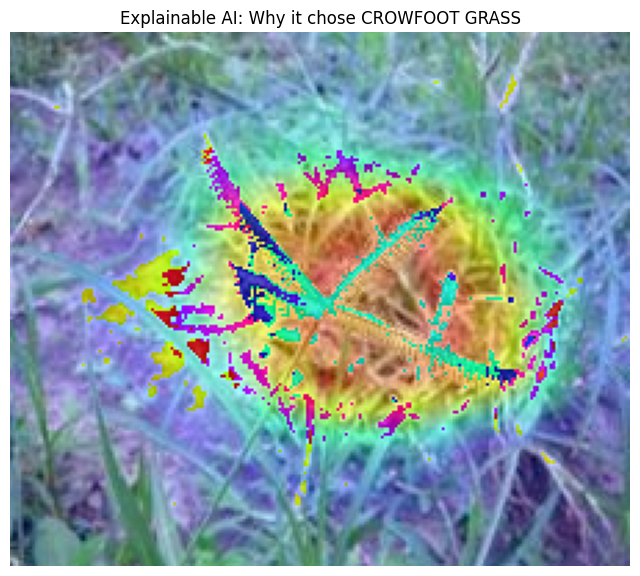

In [19]:
img_path = "/content/test.jpg"

print("Running Prediction & Farm Advisor Logic...")
label = predict_with_advice(img_path)

print("Generating Explainable AI Heatmap...")
get_gradcam(img_path)

In [18]:
from google.colab import files
uploaded_file = files.upload()

Saving 03e0ed29-50c9-4872-b174-8d8287b33cfa.jpeg to 03e0ed29-50c9-4872-b174-8d8287b33cfa.jpeg


In [20]:
base_model.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(train_ds, validation_data=val_ds, epochs=5)

Epoch 1/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 37s 834ms/step - accuracy: 0.7161 - loss: 1.2488 - val_accuracy: 1.0000 - val_loss: 0.0257
Epoch 2/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 289ms/step - accuracy: 0.7677 - loss: 0.9951 - val_accuracy: 1.0000 - val_loss: 0.0232
Epoch 3/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 274ms/step - accuracy: 0.7742 - loss: 0.8458 - val_accuracy: 1.0000 - val_loss: 0.0211
Epoch 4/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 281ms/step - accuracy: 0.7935 - loss: 0.6833 - val_accuracy: 1.0000 - val_loss: 0.0197
Epoch 5/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 273ms/step - accuracy: 0.8323 - loss: 0.5751 - val_accuracy: 1.0000 - val_loss: 0.0189


In [21]:
callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

model.fit(train_ds, validation_data=val_ds, epochs=20, callbacks=[callback])

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 400ms/step - accuracy: 0.8452 - loss: 0.5322 - val_accuracy: 1.0000 - val_loss: 0.0181
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 302ms/step - accuracy: 0.8645 - loss: 0.4737 - val_accuracy: 1.0000 - val_loss: 0.0179
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 290ms/step - accuracy: 0.8645 - loss: 0.3353 - val_accuracy: 1.0000 - val_loss: 0.0174
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 290ms/step - accuracy: 0.9161 - loss: 0.2589 - val_accuracy: 1.0000 - val_loss: 0.0171
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 268ms/step - accuracy: 0.9161 - loss: 0.2211 - val_accuracy: 1.0000 - val_loss: 0.0172
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 277ms/step - accuracy: 0.9290 - loss: 0.1781 - val_accuracy: 1.0000 - val_loss: 0.0172
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 279ms/step - accuracy: 0.9419 - loss: 0.1669 - val_accuracy: 1.0000 - val_loss: 0.0171


In [22]:
loss, acc = model.evaluate(val_ds)
print(f"Validation Accuracy: {acc*100:.2f}%")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 1.0000 - loss: 0.0171
Validation Accuracy: 100.00%
